# Docking-in-the-loop molecular generation with an uncertainty-guarded reward

## Abstract

A docking score is a fast but biased estimate of binding. Using it directly as a generative reward invites reward-hacking: the optimizer exploits the oracle rather than finding real binders. We ask whether an uncertainty penalty keeps the optimizer honest. We train a Gaussian-process surrogate on 9,611 EGFR docking scores. Its mean uses a combined kernel (FCFP Tanimoto, physicochemical RBF, 3D-shape RBF) and reaches R² = 0.87 on a random split; its uncertainty uses a separate Tanimoto-kernel GP whose σ tracks structural distance to the training set (Spearman(similarity, σ) = −0.75). A REINVENT agent then optimizes four rewards that share two fixed quality terms, drug-likeness (QED) and synthetic accessibility, and differ only in how docking enters: no docking, a naive docking mean (μ), a pessimistic docking term (μ − λσ), and the pessimistic term with active learning. Over five replicates, every docking reward reaches far better real binding than the no-docking baseline (−8.6 vs −7.3 kcal/mol), and the pessimistic reward keeps the surrogate conservative (a surrogate-minus-real gap of −0.05 against +0.05 for the baseline). The pessimism does not correct the oracle's own size and lipophilicity bias: in every docking condition the best candidates drift to higher logP (≈5 vs 3.8), higher molecular weight (≈375 vs 320) and lower QED (≈0.6 vs 0.75). The guard does what it is designed to do, and the experiment shows what it cannot: a biased oracle needs a different kind of guard.

## Introduction

Reinforcement-learning generators optimize whatever reward they are given. When that reward is a learned surrogate, the agent is adversarial by construction: it climbs the reward surface into regions where the surrogate is confident and wrong. Docking makes this worse, because the score itself rewards hydrophobic bulk rather than genuine complementarity. This notebook builds a docking surrogate with a calibrated uncertainty, uses the lower confidence bound μ − λσ as a pessimistic reward, and tests across replicates whether pessimism and active learning change what the agent produces. The result separates two failure modes that are easy to conflate: surrogate error, which pessimism addresses, and oracle bias, which it does not.

## Methods

### EGFR docking dataset

About ten thousand drug-like molecules from ChEMBL were docked into EGFR (PDB 1M17) with smina, the search box taken from the co-crystal ligand. 9,611 molecules scored successfully (96%). The setup was validated beforehand by redocking the native ligand (RMSD 1.5 Å) and by enrichment of known actives over decoys (AUC 0.79). Throughout, the regression target is s = −affinity, so that higher is a better binder. Erlotinib, a marketed EGFR inhibitor, docks at −7.6 kcal/mol and sits as a reference.

In [1]:
import matplotlib.pyplot as plt
import numpy as np, pandas as pd, joblib, random, glob, os
from xgboost import XGBRegressor
from rdkit import Chem
from rdkit.Chem import AllChem, QED, Crippen, Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import spearmanr
from rdkit import DataStructs
from scipy.linalg import cho_factor, cho_solve
from rdkit.Chem import Descriptors, rdMolDescriptors, Descriptors3D
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
import sys; sys.path.append("/mnt/c/Users/coure/Projects/cheminformatics")
%matplotlib inline
from scale_surrogate import (fcfp_bits, phys_block, fit_mu, fit_sigma_L,
    predict_mu, shape_block, predict_sigma, MU_HP, SIGMA_HP, REPO, CSV, X3DCACHE, SEED, BUNDLE)
import subprocess, tempfile, textwrap, re
import shutil, pickle
import scoring.scorer as sc


from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

REPO = "/mnt/c/Users/coure/Projects/cheminformatics"

submitted 10000 | docked 9611 (96.1% success)
count    9611.00
mean       -7.94
std         1.04
min       -12.00
25%        -8.70
50%        -8.00
75%        -7.30
max        -3.80
Name: affinity, dtype: float64


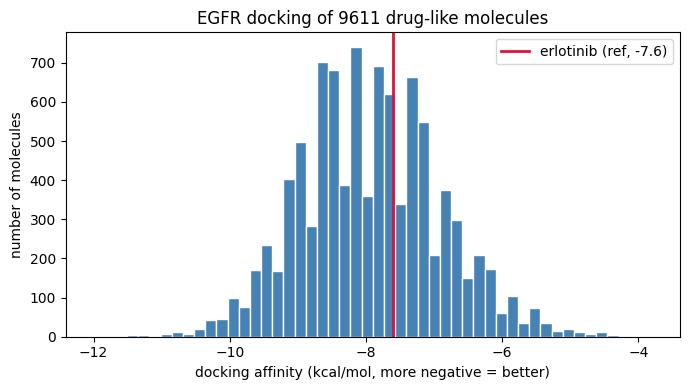


Top 10 binders (most negative):
                                                                                 smiles  affinity
   CO[C@H]1[C@H](O)[C@H]2[C@@H](O[C@@H]1CO)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4=O     -12.0
                     O=C1NC(=O)c2c1c1c3ccccc3n3c1c1c2c2ccccc2n1[C@@H]1O[C@H]3C[C@@H]1CO     -11.7
CO[C@H]1[C@H](O)[C@H]2[C@@H](O[C@@H]1CO)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)N(C)C4=O     -11.7
                                      O=C1NC(=O)c2c1c1c3ccccc3n3c1c1c2c2ccccc2n1CN(O)C3     -11.5
                                            O=C1c2c(O)cccc2Cc2ccc(Cc3cc(O)ccc3O)c(O)c21     -11.5
                          Nc1cc(-n2cc(C(=O)O)c(=O)c3cc(F)c(N4CC[C@H](N)C4)cc32)c(F)cc1F     -11.4
                             Nc1cc(-n2cc(C(=O)O)c(=O)c3cc(F)c(N4CCNCC4)c(F)c32)c(F)cc1F     -11.4
                            NC1=NC(=O)c2c1c1c3ccccc3n3c1c1c2c2ccccc2n1[C@@H]1CC[C@H]3O1     -11.4
             CN[C@@H]1CC2O[C@@](C)([C@@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)O

In [2]:
parts = glob.glob(f"{REPO}/dock_seed/out/*_out.csv")
raw = pd.concat([pd.read_csv(f) for f in parts], ignore_index=True)
raw["affinity"] = pd.to_numeric(raw["affinity"], errors="coerce")
n_total = len(raw)
df = raw.dropna(subset=["affinity"]).drop_duplicates("smiles").reset_index(drop=True)
df.to_csv(f"{REPO}/models/docking_seed.csv", index=False)

print(f"submitted {n_total} | docked {len(df)} ({100*len(df)/n_total:.1f}% success)")
print(df["affinity"].describe().round(2))

plt.figure(figsize=(7, 4))
plt.hist(df["affinity"], bins=50, color="steelblue", edgecolor="white")
plt.axvline(-7.6, color="crimson", lw=2, label="erlotinib (ref, -7.6)")
plt.xlabel("docking affinity (kcal/mol, more negative = better)")
plt.ylabel("number of molecules")
plt.title(f"EGFR docking of {len(df)} drug-like molecules")
plt.legend(); plt.tight_layout(); plt.show()

print("\nTop 10 binders (most negative):")
print(df.nsmallest(10, "affinity")[["smiles", "affinity"]].to_string(index=False))

### A surrogate for the docking score

A generative reward is queried far more often than docking can run, so the docking score must be approximated by a fast surrogate. Two things are needed: an accurate mean, and an uncertainty that can be trusted, both to penalize extrapolation (pessimism) and to drive data acquisition (active learning). A first XGBoost model predicted the mean well but gave an uncalibrated uncertainty: its bootstrap σ barely ranked the error (Spearman ≈ 0.01). We therefore moved to a Gaussian process, whose uncertainty is built into the model rather than estimated after the fact. The model is developed on a 1,500-molecule subset before scaling.

In [3]:
df = pd.read_csv(f"{REPO}/models/docking_seed.csv").dropna(subset=["affinity"]).reset_index(drop=True)
df["s"] = -df["affinity"]                      # score: higher = better binder

sub = df.sample(1500, random_state=0).reset_index(drop=True)
fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, 2048) for s in sub["smiles"]]
y = sub["s"].values
print(len(fps), "molecules | s from", round(y.min(),2), "to", round(y.max(),2))

1500 molecules | s from 4.6 to 11.5


shape: (1500, 1500)
diagonal (Tanimoto with itself): [1. 1. 1. 1. 1.]
mean off-diagonal similarity 0.106


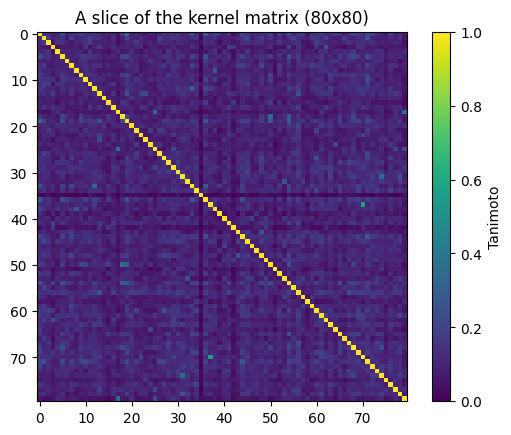

In [4]:
def tanimoto_kernel(fps_a, fps_b):
    # K[i,j] = Tanimoto(a_i, b_j) ; BulkTanimotoSimilarity is C++, fast
    K = np.zeros((len(fps_a), len(fps_b)))
    for i, fa in enumerate(fps_a):
        K[i, :] = DataStructs.BulkTanimotoSimilarity(fa, fps_b)
    return K

K = tanimoto_kernel(fps, fps)                  # 1500 x 1500
print("shape:", K.shape)
print("diagonal (Tanimoto with itself):", K.diagonal()[:5])          
print("mean off-diagonal similarity", round((K.sum()-K.trace())/(K.size-len(K)), 3))

import matplotlib.pyplot as plt
plt.imshow(K[:80, :80], cmap="viridis"); plt.colorbar(label="Tanimoto")
plt.title("A slice of the kernel matrix (80x80)"); plt.show()

In [5]:
rng = np.random.default_rng(0)
perm = rng.permutation(len(fps))
tr, te = perm[:1200], perm[1200:]              # 1200 train / 300 test

sn2 = 0.5**2                                    # docking noise variance (~0.5 kcal/mol)
mu_y = y[tr].mean()                             # the GP assumes zero mean -> we center y

Ktr = K[np.ix_(tr, tr)]                         # kern train-train
L = cho_factor(Ktr + sn2*np.eye(len(tr)), lower=True)   # factorization of (K + sn^2 I)
alpha = cho_solve(L, y[tr] - mu_y)             # (K + sn^2 I)^-1 (y - mean)

Ks = K[np.ix_(te, tr)]                          # similarity test -> train
mu = Ks @ alpha + mu_y                          # predictive mean

v = cho_solve(L, Ks.T)
kss = K[te, te]                                 # = 1 (Tanimoto with itself) = prior variance
var = kss - np.einsum('ij,ji->i', Ks, v)        # <-- prior minus what the data explains
sigma = np.sqrt(np.clip(var, 1e-9, None))       # <-- uncertainty

err = np.abs(mu - y[te])
print(f"GP | R2 = {r2_score(y[te], mu):.3f} | RMSE = {mean_squared_error(y[te], mu)**0.5:.3f}")
print(f"calibration sigma vs |err| : Spearman = {spearmanr(sigma, err).correlation:.3f}")
q = pd.qcut(sigma, 4, labels=["σ low","σ mid-","σ mid+","σ high"])
print(pd.DataFrame({"sigma":sigma,"err":err,"q":q}).groupby("q", observed=True)[["sigma","err"]].mean().round(3))

GP | R2 = 0.687 | RMSE = 0.594
calibration sigma vs |err| : Spearman = 0.216
        sigma    err
q                   
σ low   0.673  0.358
σ mid-  0.759  0.385
σ mid+  0.793  0.525
σ high  0.841  0.584


In [6]:
for sn in [0.1, 0.3, 0.5, 0.8, 1.2]:
    L = cho_factor(K[np.ix_(tr,tr)] + sn**2*np.eye(len(tr)), lower=True)
    alpha = cho_solve(L, y[tr] - mu_y)
    Ks = K[np.ix_(te,tr)]
    mu = Ks @ alpha + mu_y
    v = cho_solve(L, Ks.T)
    sg = np.sqrt(np.clip(K[te,te] - np.einsum('ij,ji->i', Ks, v), 1e-9, None))
    from sklearn.metrics import r2_score
    from scipy.stats import spearmanr
    print(f"sn={sn}: R2={r2_score(y[te],mu):.3f}  Spearman(sigma,err)={spearmanr(sg, np.abs(mu-y[te])).correlation:.3f}")

sn=0.1: R2=0.698  Spearman(sigma,err)=0.178
sn=0.3: R2=0.695  Spearman(sigma,err)=0.195
sn=0.5: R2=0.687  Spearman(sigma,err)=0.216
sn=0.8: R2=0.660  Spearman(sigma,err)=0.232
sn=1.2: R2=0.609  Spearman(sigma,err)=0.228


In [7]:
Ktr = K[np.ix_(tr, tr)]
yc  = y[tr] - y[tr].mean()
n   = len(tr)

def log_ml(sf2, sn2):
    A = sf2 * Ktr + sn2 * np.eye(n)              # cov = sigma_f^2 * K + sigma_n^2 * I
    c, low = cho_factor(A, lower=True)
    alpha  = cho_solve((c, low), yc)
    fit     = -0.5 * yc @ alpha                  # fit term
    complexity = -np.sum(np.log(np.diag(c)))     # = -0.5 log|A|
    return fit + complexity - 0.5 * n * np.log(2*np.pi)

best = None
for sf in [0.5, 1, 2, 3]:
    for sn in [0.1, 0.3, 0.5, 0.8, 1.2]:
        v = log_ml(sf**2, sn**2)
        print(f"sf={sf} sn={sn}: logML = {v:.1f}")
        if best is None or v > best[0]:
            best = (v, sf, sn)
print("\nBEST (max logML):", best)

sf=0.5 sn=0.1: logML = -1665.9
sf=0.5 sn=0.3: logML = -1457.7
sf=0.5 sn=0.5: logML = -1395.5
sf=0.5 sn=0.8: logML = -1481.2
sf=0.5 sn=1.2: logML = -1688.3
sf=1 sn=0.1: logML = -1270.3
sf=1 sn=0.3: logML = -1306.4
sf=1 sn=0.5: logML = -1378.1
sf=1 sn=0.8: logML = -1525.1
sf=1 sn=1.2: logML = -1742.3
sf=2 sn=0.1: logML = -1776.4
sf=2 sn=0.3: logML = -1794.7
sf=2 sn=0.5: logML = -1831.3
sf=2 sn=0.8: logML = -1909.4
sf=2 sn=1.2: logML = -2038.7
sf=3 sn=0.1: logML = -2201.2
sf=3 sn=0.3: logML = -2209.9
sf=3 sn=0.5: logML = -2229.0
sf=3 sn=0.8: logML = -2271.5
sf=3 sn=1.2: logML = -2347.6

BEST (max logML): (np.float64(-1270.3450002735615), 1, 0.1)


In [8]:
_, sf, sn = best
Kf_tr = sf**2 * K[np.ix_(tr, tr)]
L = cho_factor(Kf_tr + sn**2*np.eye(len(tr)), lower=True)
alpha = cho_solve(L, y[tr] - y[tr].mean())
Kf_s = sf**2 * K[np.ix_(te, tr)]
mu = Kf_s @ alpha + y[tr].mean()
v = cho_solve(L, Kf_s.T)
var = sf**2 * K[te, te] - np.einsum('ij,ji->i', Kf_s, v)
sg = np.sqrt(np.clip(var, 1e-9, None))
print(f"hyperparameters chosen by logML: sf={sf}, sn={sn}")
print(f"test | R2={r2_score(y[te],mu):.3f} | Spearman(sigma,err)={spearmanr(sg,np.abs(mu-y[te])).correlation:.3f}")

hyperparameters chosen by logML: sf=1, sn=0.1
test | R2=0.698 | Spearman(sigma,err)=0.178


### Adding features: a combined kernel

The Tanimoto-kernel GP captures structure alone. We add eight physicochemical descriptors and six 3D-shape descriptors, encode structure as functional-class fingerprints (FCFP), and combine three kernels, a²·Tanimoto(FCFP) + b²·RBF(phys) + c²·RBF(3D), with weights and length-scales tuned by marginal likelihood. The combined mean improves on the subset (R² 0.69 to 0.82). Its uncertainty, however, collapses: marginal likelihood optimizes predictive fit, not calibration, and the smooth RBF trend flattens σ (Spearman(σ, error) falls from 0.22 to 0.06). The mean and the uncertainty want different representations. We therefore decouple them: the combined kernel supplies the mean μ, the Tanimoto kernel supplies the uncertainty σ. The pessimistic reward μ − λσ draws each from the model that estimates it best.

In [9]:
mols = [Chem.MolFromSmiles(s) for s in sub["smiles"]]   

# --- 1. Structure: FCFP4 (Morgan functional-class) ---
fcfp = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048, useFeatures=True) for m in mols]

# --- 2. 2D physicochemistry (continuous) ---
def phys(m):
    return [Descriptors.MolWt(m), Descriptors.MolLogP(m), Descriptors.TPSA(m),
            Descriptors.NumHDonors(m), Descriptors.NumHAcceptors(m),
            Descriptors.NumRotatableBonds(m), rdMolDescriptors.CalcNumAromaticRings(m),
            rdMolDescriptors.CalcFractionCSP3(m)]
Xphys = np.array([phys(m) for m in mols], float)

# --- 3. 3D shape (needs a conformer) ---
def shape(m):
    mh = Chem.AddHs(m)
    if AllChem.EmbedMolecule(mh, randomSeed=0) != 0:
        return [np.nan]*6
    AllChem.MMFFOptimizeMolecule(mh)
    return [Descriptors3D.Asphericity(mh), Descriptors3D.Eccentricity(mh),
            Descriptors3D.NPR1(mh), Descriptors3D.NPR2(mh),
            Descriptors3D.RadiusOfGyration(mh), Descriptors3D.SpherocityIndex(mh)]
X3d = np.array([shape(m) for m in mols], float)

print("FCFP:", len(fcfp), "| phys:", Xphys.shape, "| 3D:", X3d.shape,
      "| 3D failures:", np.isnan(X3d).any(1).sum())

FCFP: 1500 | phys: (1500, 8) | 3D: (1500, 6) | 3D failures: 0


In [10]:
rng = np.random.default_rng(0); perm = rng.permutation(len(fcfp))
tr, te = perm[:1200], perm[1200:]
ytr = y[tr]; mu_y = ytr.mean(); ytr_c = ytr - mu_y

# --- FCFP Tanimoto (no hyperparameter) ---
def tani(A, B):
    K = np.zeros((len(A), len(B)))
    for i, a in enumerate(A): K[i, :] = DataStructs.BulkTanimotoSimilarity(a, B)
    return K
Ff = [fcfp[i] for i in tr]; Ft = [fcfp[i] for i in te]
Kf_tt, Kf_st = tani(Ff, Ff), tani(Ft, Ff)

# --- standardize ON THE TRAIN SET, then squared distances ---
sp = StandardScaler().fit(Xphys[tr]); Pp_tr, Pp_te = sp.transform(Xphys[tr]), sp.transform(Xphys[te])
s3 = StandardScaler().fit(X3d[tr]);   P3_tr, P3_te = s3.transform(X3d[tr]),   s3.transform(X3d[te])
sq = lambda A, B: ((A[:, None, :] - B[None, :, :])**2).sum(-1)
Dp_tt, Dp_st = sq(Pp_tr, Pp_tr), sq(Pp_te, Pp_tr)
D3_tt, D3_st = sq(P3_tr, P3_tr), sq(P3_te, P3_tr)

def kernels(theta, train=True):
    a, b, c, lp, l3, sn = np.exp(theta)          # exp -> everything is positive
    if train:
        K = a*Kf_tt + b*np.exp(-Dp_tt/(2*lp**2)) + c*np.exp(-D3_tt/(2*l3**2))
        return K, sn, (a+b+c)
    return a*Kf_st + b*np.exp(-Dp_st/(2*lp**2)) + c*np.exp(-D3_st/(2*l3**2))

n = len(tr)
def neg_log_ml(theta):
    K, sn, _ = kernels(theta, True)
    A = K + (sn**2 + 1e-6)*np.eye(n)
    try: c_, low = cho_factor(A, lower=True)
    except Exception: return 1e12
    alpha = cho_solve((c_, low), ytr_c)
    return 0.5*ytr_c@alpha + np.sum(np.log(np.diag(c_))) + 0.5*n*np.log(2*np.pi)

x0 = np.log([1.0, 0.5, 0.5, 2.0, 2.0, 0.5])
res = minimize(neg_log_ml, x0, method="L-BFGS-B")
a, b, c, lp, l3, sn = np.exp(res.x)
print(f"optimised weights : a(FCFP)={a:.2f}  b(phys)={b:.2f}  c(3D)={c:.2f} | lp={lp:.2f} l3={l3:.2f} sn={sn:.2f}")

# --- evaluation on the test ---
K, sn_, kss = kernels(res.x, True)
L = cho_factor(K + (sn_**2 + 1e-6)*np.eye(n), lower=True)
alpha = cho_solve(L, ytr_c)
Ks = kernels(res.x, False)
mu = Ks @ alpha + mu_y
v = cho_solve(L, Ks.T)
sg = np.sqrt(np.clip(kss - np.einsum('ij,ji->i', Ks, v), 1e-9, None))
err = np.abs(mu - y[te])
print(f"COMBINE  | R2={r2_score(y[te],mu):.3f} | Spearman(sigma,err)={spearmanr(sg,err).correlation:.3f}")
print("mono-Tanimoto ECFP reminder: R2=0.687 | Spearman=0.216")
print(f"sigma test : min={sg.min():.3f}  max={sg.max():.3f}  std={sg.std():.3f}  mean={sg.mean():.3f}")
print(f"y test std : {y[te].std():.3f}   (signal scale)")
print("quantiles sigma :", np.round(np.quantile(sg, [0, .25, .5, .75, 1]), 3))

optimised weights : a(FCFP)=0.26  b(phys)=37.95  c(3D)=4.54 | lp=18.09 l3=5.54 sn=0.26
COMBINE  | R2=0.822 | Spearman(sigma,err)=0.061
mono-Tanimoto ECFP reminder: R2=0.687 | Spearman=0.216
sigma test : min=0.207  max=0.461  std=0.042  mean=0.362
y test std : 1.060   (signal scale)
quantiles sigma : [0.207 0.34  0.366 0.393 0.461]


In [11]:
# bounds on the log-parameters : [a, b, c, lp, l3, sn]
bnds = [(np.log(1e-2), np.log(10)),   # a  (FCFP) 
        (np.log(1e-2), np.log(50)),   # b  (phys)
        (np.log(1e-2), np.log(50)),   # c  (3D)
        (np.log(0.5),  np.log(3.0)),  # lp : RBF phys must decay
        (np.log(0.5),  np.log(3.0)),  # l3 : RBF 3D  must decay
        (np.log(0.1),  np.log(1.0))]  # sn : realistic noise

res2 = minimize(neg_log_ml, x0, method="L-BFGS-B", bounds=bnds)
a, b, c, lp, l3, sn = np.exp(res2.x)
print(f"bounded: a(FCFP)={a:.2f} b(phys)={b:.2f} c(3D)={c:.2f} | lp={lp:.2f} l3={l3:.2f} sn={sn:.2f}")

K, sn_, kss = kernels(res2.x, True)
L = cho_factor(K + (sn_**2 + 1e-6)*np.eye(n), lower=True)
alpha = cho_solve(L, ytr_c)
Ks = kernels(res2.x, False)
mu = Ks @ alpha + mu_y
v = cho_solve(L, Ks.T)
sg = np.sqrt(np.clip(kss - np.einsum('ij,ji->i', Ks, v), 1e-9, None))
err = np.abs(mu - y[te])
print(f"COMBINED BOUNDED | R2={r2_score(y[te],mu):.3f} | Spearman={spearmanr(sg,err).correlation:.3f}")
print(f"sigma : std={sg.std():.3f} mean={sg.mean():.3f} (spread {sg.min():.2f}-{sg.max():.2f})")
print("reminders : mono-Tanimoto 0.687/0.216 | free combined 0.822/0.061")

bounded: a(FCFP)=0.26 b(phys)=0.77 c(3D)=0.45 | lp=3.00 l3=3.00 sn=0.25
COMBINED BOUNDED | R2=0.816 | Spearman=0.110
sigma : std=0.052 mean=0.382 (spread 0.22-0.58)
reminders : mono-Tanimoto 0.687/0.216 | free combined 0.822/0.061


## Validation at scale

The decoupled surrogate is refit on all 9,611 molecules and tested under three train/test splits of increasing difficulty: random, scaffold (whole Bemis-Murcko scaffolds held out), and similarity (the 20% least similar to the training core held out). The mean generalizes well throughout (R² = 0.87, 0.86, 0.85). The uncertainty behaves exactly as a distance detector should: σ rises sharply as a molecule moves away from the training set (Spearman(similarity, σ) = −0.75). On this dataset, distance barely predicts error (Spearman(similarity, error) = −0.06), because the surrogate rarely fails badly inside drug-like space. The low σ-to-error correlation is therefore a property of the data, not a flaw of σ: the decoupled uncertainty is a faithful novelty detector, which is what both pessimism and acquisition rely on.

R2=0.871 RMSE=0.374 Spearman(sig,err)=0.118


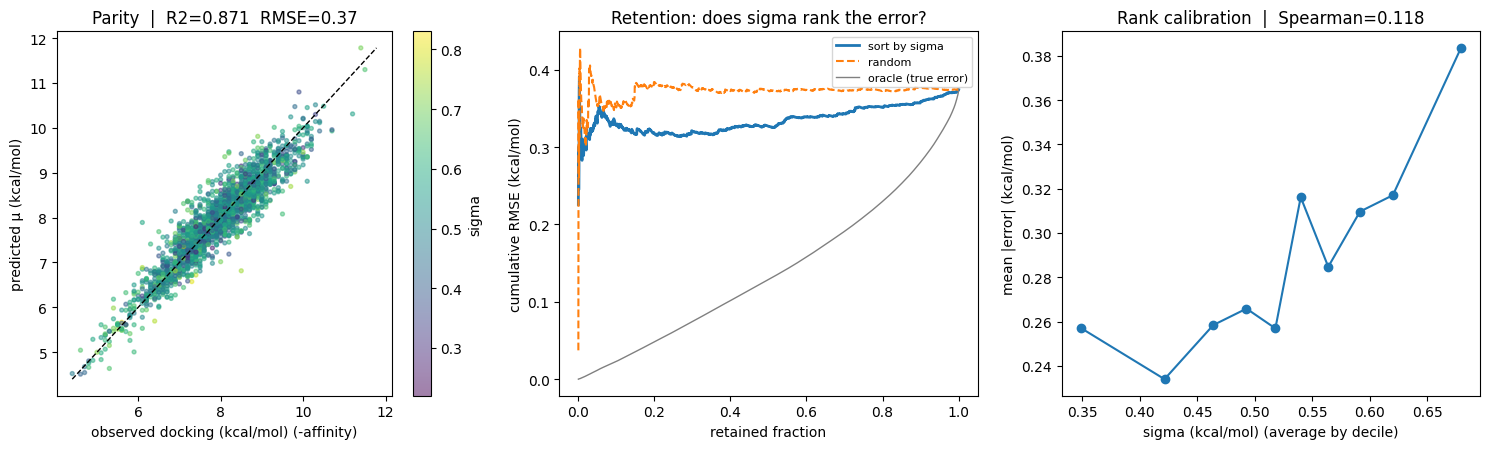

In [12]:
df = pd.read_csv(CSV)
y = -df["affinity"].to_numpy(float)
mols = [Chem.MolFromSmiles(s) for s in df["smiles"]]
keep = [i for i, m in enumerate(mols) if m is not None]
mols = [mols[i] for i in keep]; y = y[keep]
B = fcfp_bits(mols); Xphys = phys_block(mols); X3d = np.load(X3DCACHE)[keep]
X3d[np.isnan(X3d).any(1)] = np.nanmean(X3d, axis=0)
n = len(mols)

rng = np.random.default_rng(SEED); perm = rng.permutation(n); ntr = int(0.8*n)
tr, te = perm[:ntr], perm[ntr:]
sp = StandardScaler().fit(Xphys[tr]); Pt, Pe = sp.transform(Xphys[tr]), sp.transform(Xphys[te])
s3 = StandardScaler().fit(X3d[tr]);   Tt, Te = s3.transform(X3d[tr]),   s3.transform(X3d[te])
Bt, Be = B[tr].astype(np.float32), B[te].astype(np.float32)

alpha, mu_y = fit_mu(Bt, Pt, Tt, y[tr], MU_HP)
mu = predict_mu(Be, Pe, Te, Bt, Pt, Tt, alpha, mu_y, MU_HP)
L = fit_sigma_L(B[tr], SIGMA_HP)
sg = predict_sigma(B[te], B[tr], L, SIGMA_HP)
yt = y[te]; err = np.abs(mu - yt)
r2 = r2_score(yt, mu); rmse = np.sqrt((err**2).mean()); rho = spearmanr(sg, err).correlation
print(f"R2={r2:.3f} RMSE={rmse:.3f} Spearman(sig,err)={rho:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
scat_1 = ax[0].scatter(yt, mu, c=sg, s=8, alpha=.5, cmap="viridis")
lo, hi = min(yt.min(), mu.min()), max(yt.max(), mu.max())
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[0].set_xlabel("observed docking (kcal/mol) (-affinity)"); ax[0].set_ylabel("predicted µ (kcal/mol)")
ax[0].set_title(f"Parity  |  R2={r2:.3f}  RMSE={rmse:.2f}")
plt.colorbar(scat_1, ax=ax[0], label="sigma")

def ret(order):
    e = err[order]; return np.sqrt(np.cumsum(e**2)/np.arange(1, len(e)+1))
frac = np.arange(1, len(err)+1)/len(err)
ax[1].plot(frac, ret(np.argsort(sg)), label="sort by sigma", lw=2)
ax[1].plot(frac, ret(rng.permutation(len(err))), label="random", lw=1.5, ls="--")
ax[1].plot(frac, ret(np.argsort(err)), label="oracle (true error)", lw=1, color="grey")
ax[1].set_xlabel("retained fraction"); ax[1].set_ylabel("cumulative RMSE (kcal/mol)")
ax[1].set_title("Retention: does sigma rank the error?"); ax[1].legend(fontsize=8)

q = np.quantile(sg, np.linspace(0, 1, 11)); idx = np.clip(np.digitize(sg, q[1:-1]), 0, 9)
xs = [sg[idx==k].mean() for k in range(10)]; ys = [err[idx==k].mean() for k in range(10)]
ax[2].plot(xs, ys, "o-")
ax[2].set_xlabel("sigma (kcal/mol) (average by decile)"); ax[2].set_ylabel("mean |error| (kcal/mol)")
ax[2].set_title(f"Rank calibration  |  Spearman={rho:.3f}")
plt.tight_layout(); plt.show()

4616 unique scaffolds for 9611 molecules
train 7688 | test 1923 | disjoint scaffolds OK
SCAFFOLD-SPLIT | R2=0.857 RMSE=0.389 Spearman(sig,err)=0.110
reminder random-split : R2=0.871 Spearman=0.118


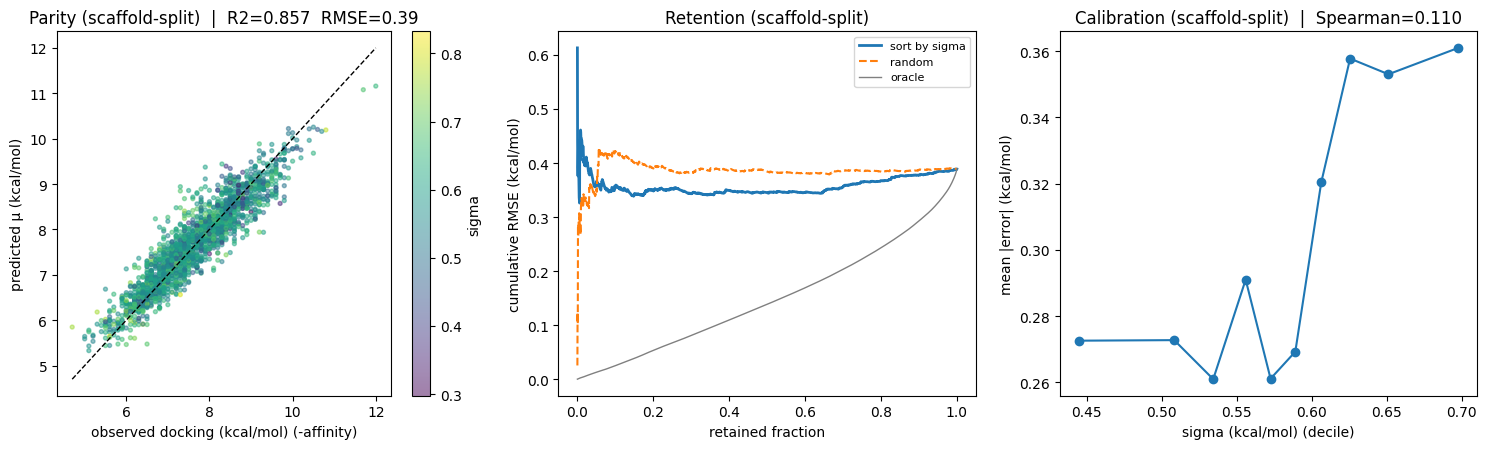

In [13]:
def scaffold_of(m):
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=m, includeChirality=False)
    except Exception:
        return ""

scaf = [scaffold_of(m) for m in mols]
groups = defaultdict(list)
for i, s in enumerate(scaf):
    groups[s].append(i)
print(f"{len(groups)} unique scaffolds for {n} molecules")

# fill the test set with whole scaffolds up to ~20%
rng = np.random.default_rng(SEED)
gorder = list(groups.values()); rng.shuffle(gorder)
te_set, target = [], int(0.2 * n)
for g in gorder:
    if len(te_set) >= target:
        break
    te_set += g
te = np.array(sorted(te_set))
tr = np.array(sorted(set(range(n)) - set(te_set)))
assert set(np.array(scaf)[tr]).isdisjoint(set(np.array(scaf)[te])), "scaffold leakage!"
print(f"train {len(tr)} | test {len(te)} | disjoint scaffolds OK")

# --- fit on train, predict on test ---
sp = StandardScaler().fit(Xphys[tr]); Pt, Pe = sp.transform(Xphys[tr]), sp.transform(Xphys[te])
s3 = StandardScaler().fit(X3d[tr]);   Tt, Te = s3.transform(X3d[tr]),   s3.transform(X3d[te])
Bt, Be = B[tr].astype(np.float32), B[te].astype(np.float32)

alpha, mu_y = fit_mu(Bt, Pt, Tt, y[tr], MU_HP)
mu = predict_mu(Be, Pe, Te, Bt, Pt, Tt, alpha, mu_y, MU_HP)
L = fit_sigma_L(B[tr], SIGMA_HP)
sg = predict_sigma(B[te], B[tr], L, SIGMA_HP)
yt = y[te]; err = np.abs(mu - yt)
r2 = r2_score(yt, mu); rmse = np.sqrt((err**2).mean()); rho = spearmanr(sg, err).correlation
print(f"SCAFFOLD-SPLIT | R2={r2:.3f} RMSE={rmse:.3f} Spearman(sig,err)={rho:.3f}")
print(f"reminder random-split : R2=0.871 Spearman=0.118")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
scat_2 = ax[0].scatter(yt, mu, c=sg, s=8, alpha=.5, cmap="viridis")
lo, hi = min(yt.min(), mu.min()), max(yt.max(), mu.max())
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[0].set_xlabel("observed docking (kcal/mol) (-affinity)"); ax[0].set_ylabel("predicted µ (kcal/mol)")
ax[0].set_title(f"Parity (scaffold-split)  |  R2={r2:.3f}  RMSE={rmse:.2f}")
plt.colorbar(scat_2, ax=ax[0], label="sigma")

def ret(order):
    e = err[order]; return np.sqrt(np.cumsum(e**2)/np.arange(1, len(e)+1))
frac = np.arange(1, len(err)+1)/len(err)
ax[1].plot(frac, ret(np.argsort(sg)), label="sort by sigma", lw=2)
ax[1].plot(frac, ret(rng.permutation(len(err))), label="random", lw=1.5, ls="--")
ax[1].plot(frac, ret(np.argsort(err)), label="oracle", lw=1, color="grey")
ax[1].set_xlabel("retained fraction"); ax[1].set_ylabel("cumulative RMSE (kcal/mol)")
ax[1].set_title("Retention (scaffold-split)"); ax[1].legend(fontsize=8)

q = np.quantile(sg, np.linspace(0, 1, 11)); idx = np.clip(np.digitize(sg, q[1:-1]), 0, 9)
xs = [sg[idx==k].mean() for k in range(10)]; ys = [err[idx==k].mean() for k in range(10)]
ax[2].plot(xs, ys, "o-")
ax[2].set_xlabel("sigma (kcal/mol) (decile)"); ax[2].set_ylabel("mean |error| (kcal/mol)")
ax[2].set_title(f"Calibration (scaffold-split)  |  Spearman={rho:.3f}")
plt.tight_layout(); plt.show()

train 7689 | test 1922 (the farthest)
test-to-train similarity: median=0.57 (vs ~0.4-0.5 typical in a random split)
SIM-SPLIT | R2=0.850 RMSE=0.408 Spearman(sig,err)=0.110
Spearman(sim,err)=-0.056  Spearman(sim,sigma)=-0.747
reminders : random R2=0.871/0.118 | scaffold R2=0.857/0.110


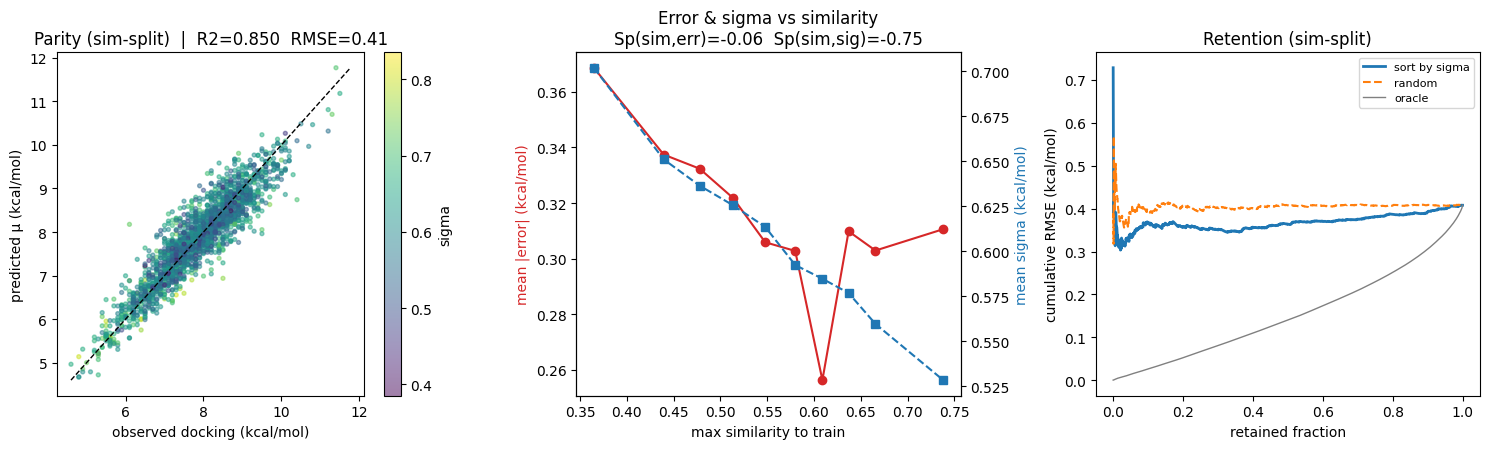

In [14]:
def max_sim_to(Bq, Bref):
    Bq = Bq.astype(np.float32); Bref = Bref.astype(np.float32)
    inter = Bq @ Bref.T
    a = Bq.sum(1); b = Bref.sum(1)
    T = inter / np.maximum(a[:, None] + b[None, :] - inter, 1e-9)
    return T.max(1)

rng = np.random.default_rng(SEED)
perm = rng.permutation(n)
core = perm[:int(0.6 * n)]; rest = perm[int(0.6 * n):]
sim_rest = max_sim_to(B[rest], B[core])          # similarity to the fixed core
k = int(0.2 * n)
order = np.argsort(sim_rest)                       # ascending = farthest first
te = rest[order[:k]]
tr = np.concatenate([core, rest[order[k:]]])
sim_te = max_sim_to(B[te], B[tr])                 # actual similarity to the final train set
print(f"train {len(tr)} | test {len(te)} (the farthest)")
print(f"test-to-train similarity: median={np.median(sim_te):.2f} "
      f"(vs ~0.4-0.5 typical in a random split)")

sp = StandardScaler().fit(Xphys[tr]); Pt, Pe = sp.transform(Xphys[tr]), sp.transform(Xphys[te])
s3 = StandardScaler().fit(X3d[tr]);   Tt, Te = s3.transform(X3d[tr]),   s3.transform(X3d[te])
Bt, Be = B[tr].astype(np.float32), B[te].astype(np.float32)

alpha, mu_y = fit_mu(Bt, Pt, Tt, y[tr], MU_HP)
mu = predict_mu(Be, Pe, Te, Bt, Pt, Tt, alpha, mu_y, MU_HP)
L = fit_sigma_L(B[tr], SIGMA_HP)
sg = predict_sigma(B[te], B[tr], L, SIGMA_HP)
yt = y[te]; err = np.abs(mu - yt)
r2 = r2_score(yt, mu); rmse = np.sqrt((err**2).mean())
rho = spearmanr(sg, err).correlation
rho_se = spearmanr(sim_te, err).correlation       # negative expected : farther -> + error
rho_ss = spearmanr(sim_te, sg).correlation        # negative expected : farther -> + sigma
print(f"SIM-SPLIT | R2={r2:.3f} RMSE={rmse:.3f} Spearman(sig,err)={rho:.3f}")
print(f"Spearman(sim,err)={rho_se:.3f}  Spearman(sim,sigma)={rho_ss:.3f}")
print(f"reminders : random R2=0.871/0.118 | scaffold R2=0.857/0.110")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
scat_3 = ax[0].scatter(yt, mu, c=sg, s=8, alpha=.5, cmap="viridis")
lo, hi = min(yt.min(), mu.min()), max(yt.max(), mu.max())
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[0].set_xlabel("observed docking (kcal/mol)"); ax[0].set_ylabel("predicted µ (kcal/mol)")
ax[0].set_title(f"Parity (sim-split)  |  R2={r2:.3f}  RMSE={rmse:.2f}")
plt.colorbar(scat_3, ax=ax[0], label="sigma")

q = np.quantile(sim_te, np.linspace(0, 1, 11)); idx = np.clip(np.digitize(sim_te, q[1:-1]), 0, 9)
xs = [sim_te[idx==k].mean() for k in range(10)]
e_bin = [err[idx==k].mean() for k in range(10)]
s_bin = [sg[idx==k].mean() for k in range(10)]
ax[1].plot(xs, e_bin, "o-", color="C3", label="|error|")
ax[1].set_xlabel("max similarity to train"); ax[1].set_ylabel("mean |error| (kcal/mol)", color="C3")
axb = ax[1].twinx(); axb.plot(xs, s_bin, "s--", color="C0", label="sigma")
axb.set_ylabel("mean sigma (kcal/mol)", color="C0")
ax[1].set_title(f"Error & sigma vs similarity\nSp(sim,err)={rho_se:.2f}  Sp(sim,sig)={rho_ss:.2f}")

def ret(order):
    e = err[order]; return np.sqrt(np.cumsum(e**2)/np.arange(1, len(e)+1))
frac = np.arange(1, len(err)+1)/len(err)
ax[2].plot(frac, ret(np.argsort(sg)), label="sort by sigma", lw=2)
ax[2].plot(frac, ret(rng.permutation(len(err))), label="random", lw=1.5, ls="--")
ax[2].plot(frac, ret(np.argsort(err)), label="oracle", lw=1, color="grey")
ax[2].set_xlabel("retained fraction"); ax[2].set_ylabel("cumulative RMSE (kcal/mol)")
ax[2].set_title("Retention (sim-split)"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Generative experiment: docking in the loop

A REINVENT 4 agent (RNN prior trained on PubChem, DAP policy gradient, σ = 128) is run for 190 steps at batch size 64, five independent replicates per condition. The reward is a geometric mean of terms. Two quality terms are held fixed in every condition, drug-likeness (QED) and synthetic accessibility, so that docking is the only potency term and the only variable is how docking enters. Four conditions are compared: a baseline with no docking, a naive docking reward on the surrogate mean μ, a pessimistic reward on the lower confidence bound μ − λσ, and the pessimistic reward with active learning. The docking terms pass through a sigmoid desirability on the surrogate output. Active learning adds three rounds per replicate: each round docks the UCB-selected candidates (high μ and high σ) for real, appends them to the training set, and refits the surrogate. Every run is evaluated by docking its final population for real, which gives the surrogate-minus-real gap (the measure of reward-hacking) and the property profile of the best candidates.

In [15]:
REINVENT_DIR = "/home/couret/REINVENT4"
ENV_REINVENT = "reinvent4"
ENV_DOCK     = "dock"
DOCK_WORKER  = f"{REPO}/dock_seed/dock_worker.py"
RUN_SUBDIR   = "dock_runs"
SEED_CSV     = f"{REPO}/models/docking_seed.csv"
CACHE3D      = f"{REPO}/models/shape_cache.pkl"
RESULTS      = f"{REPO}/rl_runs/dock_experiment_results.csv"
BETA         = 1.0
os.makedirs(f"{REINVENT_DIR}/{RUN_SUBDIR}", exist_ok=True)

TEMPLATE = '''run_type = "staged_learning"
device = "cpu"
tb_logdir = "tb_logs"

[parameters]
summary_csv_prefix = "{subdir}/{name}"
use_checkpoint = false
purge_memories = false
prior_file = "priors/reinvent.prior"
agent_file = "priors/reinvent.prior"
batch_size = 64
randomize_smiles = true

[learning_strategy]
type = "dap"
sigma = 128
rate = 0.0001

[[stage]]
chkpt_file = "{subdir}/{name}.chkpt"
termination = "simple"
max_score = 1.0
min_steps = {steps}
max_steps = {steps}

[stage.scoring]
type = "geometric_mean"

[[stage.scoring.component]]
[stage.scoring.component.Scorer]
[[stage.scoring.component.Scorer.endpoint]]
name = "{name}"
weight = 1
[stage.scoring.component.Scorer.endpoint.params]
terms = "{terms_csv}"
combine = "geometric"
'''

def run_reinvent(name, terms_csv, steps=190):
    open(f"{REINVENT_DIR}/{RUN_SUBDIR}/{name}.toml", "w").write(
        TEMPLATE.format(subdir=RUN_SUBDIR, name=name, steps=steps, terms_csv=terms_csv))
    subprocess.run(["conda", "run", "-n", ENV_REINVENT, "reinvent", f"{RUN_SUBDIR}/{name}.toml"],
        cwd=REINVENT_DIR, check=True,
        env={**os.environ, "MPLBACKEND": "Agg", "PYTHONPATH": f"{REINVENT_DIR}/contrib"})
    df = pd.read_csv(f"{REINVENT_DIR}/{RUN_SUBDIR}/{name}_1.csv").dropna(subset=["SMILES"])
    return df, df["SMILES"].drop_duplicates().tolist()

def dock_batch(smiles, tag="acq"):
    work = f"{REPO}/dock_seed/_{tag}.smi"
    open(work, "w").write("\n".join(smiles) + "\n")
    subprocess.run(["conda", "run", "-n", ENV_DOCK, "python", DOCK_WORKER, work],
        check=True, env={**os.environ, "NCORES": str(os.cpu_count())})
    d = pd.read_csv(work.replace(".smi", "_out.csv")).dropna(subset=["affinity"])
    return dict(zip(d["smiles"], d["affinity"]))

In [16]:
def acquisition(gen_smiles, k=150, beta=BETA):
    mu, sg = sc._get_surrogate()(list(gen_smiles))
    ok = np.isfinite(mu) & np.isfinite(sg)
    gs, acq = np.array(gen_smiles)[ok], (mu + beta*sg)[ok]
    seen, picks = set(), []
    for i in np.argsort(-acq):
        if gs[i] not in seen:
            seen.add(gs[i]); picks.append(gs[i])
        if len(picks) >= k: break
    return picks

def append_to_seed(aff_dict, csv=SEED_CSV):
    df = pd.read_csv(csv)
    add = pd.DataFrame({"smiles": list(aff_dict), "affinity": list(aff_dict.values())})
    pd.concat([df, add], ignore_index=True).drop_duplicates("smiles").to_csv(csv, index=False)

def refit_surrogate(csv=SEED_CSV):
    df = pd.read_csv(csv).dropna(subset=["affinity"]).drop_duplicates("smiles")
    mols = [Chem.MolFromSmiles(s) for s in df["smiles"]]
    ok = [i for i, m in enumerate(mols) if m is not None]
    mols = [mols[i] for i in ok]; smis = df["smiles"].to_numpy()[ok]; y = -df["affinity"].to_numpy(float)[ok]
    B, Xphys = fcfp_bits(mols), phys_block(mols)
    try: cache = pickle.load(open(CACHE3D, "rb"))
    except Exception: cache = {}
    new = [i for i, s in enumerate(smis) if s not in cache]
    if new:
        sh = shape_block([mols[i] for i in new])
        for j, i in enumerate(new): cache[smis[i]] = sh[j]
        pickle.dump(cache, open(CACHE3D, "wb"))
    X3d = np.array([cache[s] for s in smis], float)
    cm = np.nanmean(X3d, axis=0); inds = np.where(np.isnan(X3d)); X3d[inds] = np.take(cm, inds[1])
    spF = StandardScaler().fit(Xphys); s3F = StandardScaler().fit(X3d)
    alphaF, mu_yF = fit_mu(B.astype(np.float32), spF.transform(Xphys), s3F.transform(X3d), y, MU_HP)
    joblib.dump(dict(mu_hp=MU_HP, sigma_hp={"sf": 1.0, "sn": 0.5}, mu_y=float(mu_yF),
        train_fcfp_bits=B, train_phys_std=spF.transform(Xphys), train_shape_std=s3F.transform(X3d),
        phys_scaler=spF, shape_scaler=s3F, alpha_mu=alphaF, eval=dict(n=len(smis))), BUNDLE, compress=3)
    print(f"refit : {len(smis)} molecules (+{len(new)} 3D embedded)")

In [17]:
def final_pop(name, n=160):
    df = pd.read_csv(f"{REINVENT_DIR}/{RUN_SUBDIR}/{name}_1.csv").dropna(subset=["SMILES"])
    df["step"] = np.arange(len(df)) // 64
    return df[df["step"] >= df["step"].max()*0.75]["SMILES"].drop_duplicates().tolist()[:n]

def evaluate_run(name, cond, seed):
    pop = final_pop(name)
    mu, sg = sc._get_surrogate()(pop)
    aff = dock_batch(pop, tag=f"eval_{name}")
    real = np.array([-aff[s] if s in aff else np.nan for s in pop])
    m = np.isfinite(mu) & np.isfinite(real)
    valid = [x for x in (Chem.MolFromSmiles(s) for s in pop) if x]
    scaf = {MurckoScaffold.MurckoScaffoldSmiles(mol=x) for x in valid}
    row = dict(cond=cond, seed=seed, n=int(m.sum()),
               surr_mu=float(mu[m].mean()), real_score=float(real[m].mean()),
               hacking_gap=float((mu[m]-real[m]).mean()),
               scaffold_div=len(scaf)/max(1, len(valid)), validity=len(valid)/len(pop))
    print(row); return row

In [18]:
CONFIGS = {"baseline": "qed,sa", "naive": "dock_naive,qed,sa", "pess": "dock,qed,sa"}
results = pd.read_csv(RESULTS).to_dict("records") if os.path.exists(RESULTS) else []
done = {(r["cond"], r["seed"]) for r in results}
for cond, terms in CONFIGS.items():
    for s in range(5):
        if (cond, s) in done:
            continue
        name = f"exp_{cond}_s{s}"
        if not os.path.exists(f"{REINVENT_DIR}/{RUN_SUBDIR}/{name}_1.csv"):
            run_reinvent(name, terms, steps=190)
        results.append(evaluate_run(name, cond, s))
        pd.DataFrame(results).to_csv(RESULTS, index=False)

In [19]:
results = pd.read_csv(RESULTS).to_dict("records") if os.path.exists(RESULTS) else []
done = {(r["cond"], r["seed"]) for r in results}
if not os.path.exists(f"{REPO}/models/docking_seed_base.csv"):      
    shutil.copy(SEED_CSV, f"{REPO}/models/docking_seed_base.csv")
    shutil.copy(BUNDLE,   f"{REPO}/models/surrogate_base.joblib")

def active_learning(seed, n_rounds=3, batch=150):
    for r in range(n_rounds):
        _, gen = run_reinvent(f"exp_al_s{seed}_r{r}", "dock,qed,sa", steps=190)
        aff = dock_batch(acquisition(gen, k=batch), tag=f"al_s{seed}_r{r}")
        append_to_seed(aff); refit_surrogate(); sc._SURR = None
        print(f"[al s{seed}] round {r}: +{len(aff)} docked")
    run_reinvent(f"exp_al_s{seed}_final", "dock,qed,sa", steps=190)
    return evaluate_run(f"exp_al_s{seed}_final", "pess_al", seed)

for s in [0, 1, 2, 3, 4]:
    if ("pess_al", s) in done:
        continue
    results.append(active_learning(s))
    shutil.copy(f"{REPO}/models/docking_seed_base.csv", SEED_CSV)
    shutil.copy(f"{REPO}/models/surrogate_base.joblib", BUNDLE); sc._SURR = None
    pd.DataFrame(results).to_csv(RESULTS, index=False)

## Results

Across five replicates, all three docking rewards reach a far better real docking score than the no-docking baseline: a mean near −8.6 kcal/mol against −7.3 for the baseline. The naive mean, the pessimistic bound, and the pessimistic bound with active learning are indistinguishable on binding. They differ on the surrogate-minus-real gap, the direct measure of reward-hacking. The baseline sits at +0.05 and the naive reward near zero, the pessimistic reward is conservative at −0.045 (it predicts slightly worse than the real docking, as a lower confidence bound should), and the pessimistic reward with active learning returns to +0.015. The gaps are small and the per-replicate spread (roughly −0.15 to +0.10) places them within replicate noise. Scaffold diversity is high for every docking condition (0.94 to 0.98) and lower for the baseline (0.89).

The property profile of the fifteen best real binders per run tells the more important story. Predicted activity (pIC50), synthetic accessibility, and xTB stability are flat across conditions. Drug-likeness, lipophilicity, and size are not. Every docking condition drifts toward higher logP (median ≈ 4.5 to 5.0 against 3.8 for the baseline), higher molecular weight (≈ 370 to 380 against 320) and lower QED (≈ 0.57 for the pessimistic run against 0.75 for the baseline). The pessimistic reward does not reduce this drift; its best candidates are the most lipophilic of all. Active learning recovers a slightly healthier profile (QED ≈ 0.66, with lower logP and weight than the static pessimistic run), a consistent but modest effect.

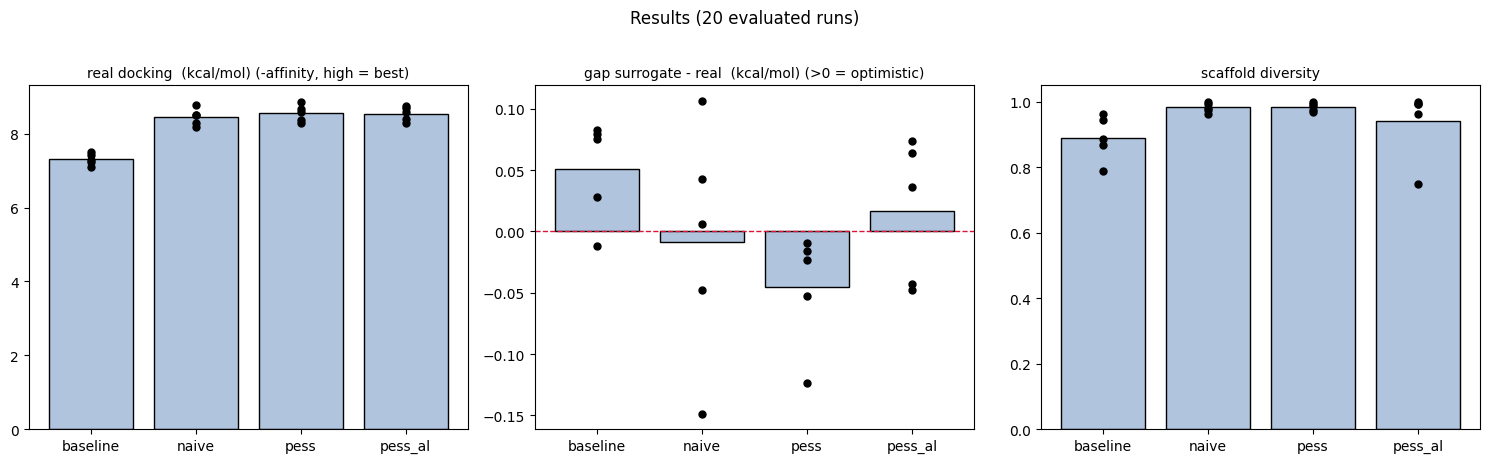

,n,real,gap,div
cond,,,,
baseline,5,7.311,0.051,0.889
naive,5,8.449,-0.008,0.982
pess,5,8.555,-0.045,0.985
pess_al,5,8.542,0.017,0.940


In [20]:
res = pd.read_csv(RESULTS)
order = [c for c in ["baseline", "naive", "pess", "pess_al"] if c in res["cond"].unique()]
metrics = [("real_score", "real docking  (kcal/mol) (-affinity, high = best)"),
           ("hacking_gap", "gap surrogate - real  (kcal/mol) (>0 = optimistic)"),
           ("scaffold_div", "scaffold diversity")]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for a, (col, title) in zip(ax, metrics):
    means = [res[res.cond == c][col].mean() for c in order]
    a.bar(order, means, color="lightsteelblue", edgecolor="k", zorder=1)
    for i, c in enumerate(order):                      # points per seed
        v = res[res.cond == c][col]
        a.scatter([i]*len(v), v, color="k", s=25, zorder=2)
    a.set_title(title, fontsize=10)
    if col == "hacking_gap":
        a.axhline(0, color="crimson", lw=1, ls="--")
plt.suptitle(f"Results ({len(res)} evaluated runs)", y=1.02)
plt.tight_layout(); plt.show()

res.groupby("cond").agg(n=("seed", "size"), real=("real_score", "mean"),
    gap=("hacking_gap", "mean"), div=("scaffold_div", "mean")).round(3)

/tmp/ipykernel_944/2781404145.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([cand[cand.cond == c][col] for c in order], labels=order, showfliers=False)
/tmp/ipykernel_944/2781404145.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([cand[cand.cond == c][col] for c in order], labels=order, showfliers=False)
/tmp/ipykernel_944/2781404145.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([cand[cand.cond == c][col] for c in order], labels=order, showfliers=False)
/tmp/ipykernel_944/2781404145.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been rename

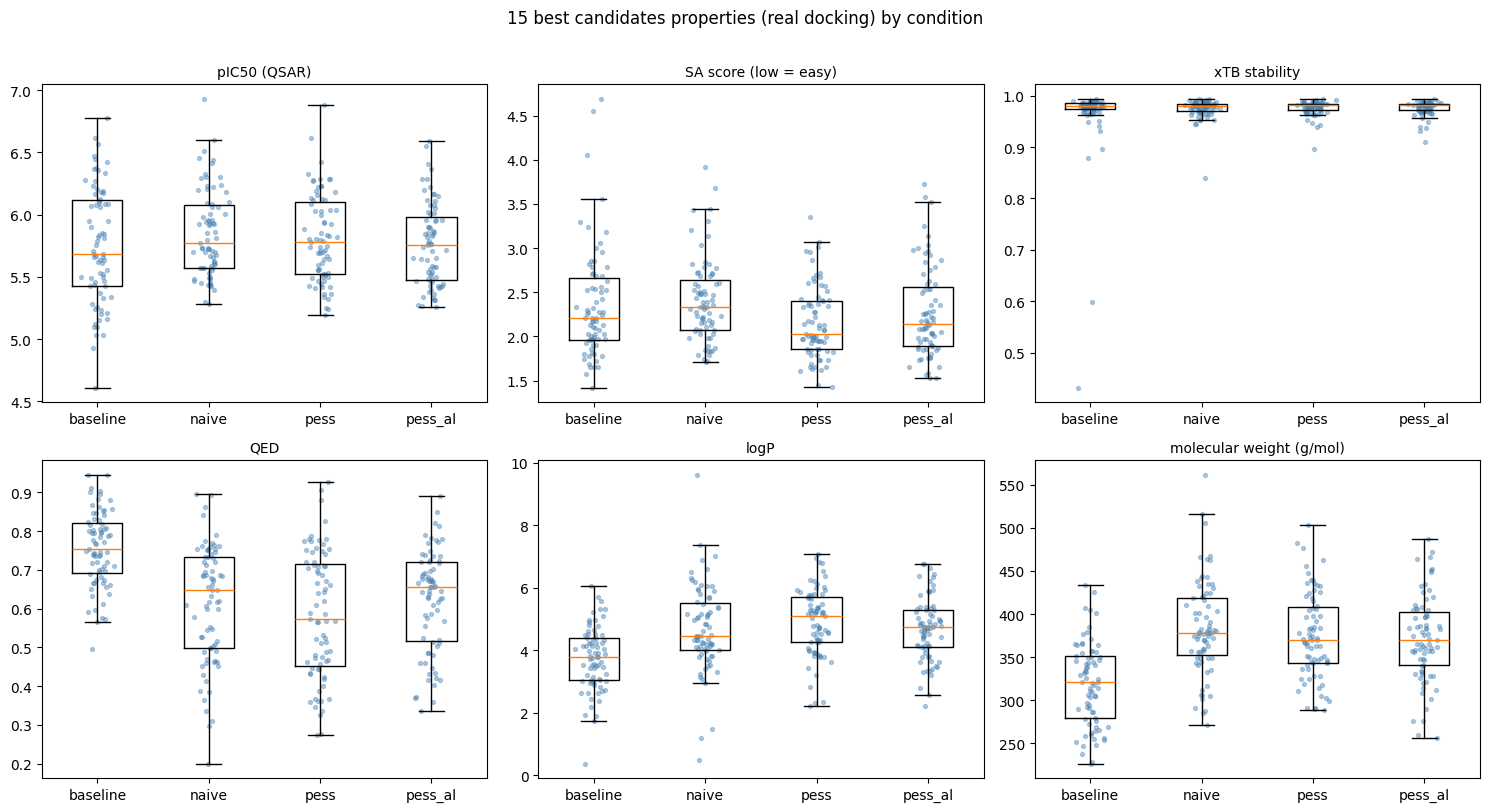

,affinity,pIC50,SA,xtb_stab,QED,logP,MW
cond,,,,,,,
baseline,-8.80,5.75,2.36,0.96,0.75,3.74,318.54
naive,-9.95,5.85,2.40,0.98,0.61,4.69,383.95
pess,-9.95,5.81,2.15,0.98,0.58,4.91,374.74
pess_al,-10.01,5.76,2.27,0.98,0.62,4.68,371.42


In [21]:
TOPK = 15
rows = []
for f in glob.glob(f"{REPO}/dock_seed/_eval_exp_*_out.csv"):
    m = re.search(r"_eval_exp_(al|baseline|naive|pess)_s(\d+)", os.path.basename(f))
    if not m: continue
    cond = "pess_al" if m.group(1) == "al" else m.group(1)
    d = pd.read_csv(f).dropna(subset=["affinity"]).sort_values("affinity").head(TOPK)  # best binders
    for smi, aff in zip(d["smiles"], d["affinity"]):
        mol = Chem.MolFromSmiles(smi)
        if mol is None: continue
        X = sc.feat(mol); fp = np.asarray(sc.compute_fp(mol)).reshape(1, -1)
        rows.append(dict(cond=cond, affinity=aff,
            pIC50=float(np.mean([mm.predict(X)[0] for mm in sc.ensemble])),
            SA=sc.sascorer.calculateScore(mol),
            xtb_stab=1.0 - float(sc.xtb_clf.predict_proba(fp)[0, 1]),
            QED=QED.qed(mol), logP=Crippen.MolLogP(mol), MW=Descriptors.MolWt(mol)))
cand = pd.DataFrame(rows)

props = [("pIC50", "pIC50 (QSAR)"), ("SA", "SA score (low = easy)"),
         ("xtb_stab", "xTB stability"), ("QED", "QED"),
         ("logP", "logP"), ("MW", "molecular weight (g/mol)")]
order = [c for c in ["baseline", "naive", "pess", "pess_al"] if c in cand.cond.unique()]
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for a, (col, title) in zip(ax.ravel(), props):
    a.boxplot([cand[cand.cond == c][col] for c in order], labels=order, showfliers=False)
    for i, c in enumerate(order):
        v = cand[cand.cond == c][col]
        a.scatter(np.random.normal(i+1, 0.06, len(v)), v, s=8, alpha=.4, color="steelblue")
    a.set_title(title, fontsize=10)
plt.suptitle(f"{TOPK} best candidates properties (real docking) by condition", y=1.01)
plt.tight_layout(); plt.show()

cand.groupby("cond")[["affinity","pIC50","SA","xtb_stab","QED","logP","MW"]].mean().round(2)

## Discussion

The decoupled surrogate works as intended. The combined kernel predicts the docking mean accurately and generalizes across scaffolds and to structurally distant molecules, while the Tanimoto σ remains a faithful novelty detector. Using each model for the quantity it estimates best is the practical lesson: a single model tuned by marginal likelihood optimizes fit, not calibration.

The pessimism behaves exactly as designed and, on this problem, changes little. Its gap is conservative by construction, but the effect sizes are within replicate noise, and no condition produces hacked molecules. The reason is the surrogate itself: inside drug-like space it rarely fails badly, so the regime where a lower confidence bound matters, severe extrapolation into the surrogate's blind spots, is barely triggered. A sterner test would need an oracle the agent can break more easily, or a chemical space far from the training set.

The clearest result is a negative one. In every docking condition the best candidates grow larger and more lipophilic and lose drug-likeness, and the pessimism does not stop it. This is not surrogate error but oracle bias: docking genuinely rewards hydrophobic bulk, those molecules lie inside the training domain where σ is low, and μ − λσ has no reason to penalize them. Pessimism guards against the surrogate disagreeing with the oracle. It cannot guard against the oracle disagreeing with reality. Correcting that drift needs guards of a different kind, explicit property constraints (a logD window, a molecular-weight cap, ligand efficiency) and, ultimately, a less biased oracle such as an MM/GBSA or free-energy rescoring.

The study is limited to a single target, uses docking as ground truth without experimental validation, runs a modest 190-step budget, and reports effects that are often small relative to replicate variance. The active-learning signal in particular should be read as suggestive rather than established.

## Conclusion

We built a calibrated, decoupled Gaussian-process surrogate for EGFR docking and used its lower confidence bound as a pessimistic reward for de novo generation, with an active-learning loop. The guard does its job, stays conservative, and preserves binding and diversity. The experiment also draws a clean line between two failure modes: pessimism addresses surrogate error, not oracle bias. The persistent size and lipophilicity drift motivates the next steps, a synthesizability guard by retrosynthesis and developability terms (ADMET), on the way to a physics-based binding oracle.